In [1]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import os

# scifact
# arguana
# nfcorpus
# scidocs
# fiqa

def data_loader(dataset: str):
    url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
    data_path = util.download_and_unzip(url, "data")

    corpus_path = os.path.join(data_path, "corpus.jsonl")
    queries_path = os.path.join(data_path, "queries.jsonl")
    qrels_path = os.path.join(data_path, "qrels", "test.tsv")

    corpus, queries, qrels = GenericDataLoader(
        corpus_file=corpus_path,
        query_file=queries_path,
        qrels_file=qrels_path
    ).load_custom()
    return corpus, queries, qrels


c:\Users\Axel\Desktop\lsa rocchio knn\BEIR_lsa_rocchio_knn\venv\Lib\site-packages\beir\util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
import spacy

nlp = spacy.load("en_core_web_sm")

def tokenize(s):
    s = nlp(s)
    tokens = [token.text.lower()
              for token in s
              if not token.is_punct and not token.is_stop and not token.is_space]
    return tokens

def clean_data(corpus: dict, queries: dict):
    cleaned_corpus = {}
    for doc_id, doc in corpus.items():
        title = doc.get("title", "")
        text = doc.get("text", "")
        full_text = title + " " + text
        tokens = tokenize(full_text)
        cleaned_corpus[doc_id] = {"text": " ".join(tokens)}

    cleaned_queries = {}
    for query_id, query_text in queries.items():
        tokens = tokenize(query_text)
        cleaned_queries[query_id] = {"text": " ".join(tokens)}

    return cleaned_corpus, cleaned_queries

In [4]:
corpus, queries, qrels = data_loader("fiqa")
cleaned_corpus, cleaned_queries = clean_data(corpus, queries)

data\fiqa.zip: 100%|██████████| 17.1M/17.1M [00:01<00:00, 10.8MiB/s]
100%|██████████| 57638/57638 [00:00<00:00, 208442.59it/s]


In [15]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

class LSAModel:
    def __init__(self,
             # LSA
             k_components="auto", tau=0.9, min_k=100, max_k=500, prefit_components=1000,
             
             # Rocchio PRF
             rocchio_prf=False, expansion_nb=30, alpha=1.0, beta=0.75, gamma=0.25,
             
             # kNN latent
             knn_search=False, k_knn=10):
        
        # Corpus
        self.doc_ids = []
        self.doc_texts = []

         # LSA
        self.vectorizer = TfidfVectorizer(sublinear_tf=True)
        self.k_components = k_components
        self.tau = tau
        self.min_k = min_k
        self.max_k = max_k
        self.prefit_components = prefit_components
        self.svd = None
        self.doc_vectors = None

        # Rocchio PRF
        self.rocchio_prf = rocchio_prf
        self.expansion_nb = expansion_nb
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        # kNN latent
        self.knn_search = knn_search
        self.k_knn = k_knn
        self.nn_model = None

    def select_k_by_variance(self, S):
        explained = np.cumsum(S**2) / np.sum(S**2)
        k = np.searchsorted(explained, self.tau) + 1
        k = min(max(k, self.min_k), self.max_k)
        
        plt.plot(np.arange(1, len(S)+1), np.cumsum(S**2)/np.sum(S**2))
        plt.axhline(y=self.tau, color='r', linestyle='--')
        plt.xlabel("Nombre de composantes k")
        plt.ylabel("Variance expliquée cumulée")
        plt.show()
        return k

    def fit(self, corpus):
        self.doc_ids = list(corpus.keys())
        self.doc_texts = [doc["text"] for doc in corpus.values()]
        tfidf_matrix = self.vectorizer.fit_transform(self.doc_texts)

        if self.k_components == "auto":
            prefit = TruncatedSVD(
                n_components=min(self.prefit_components, tfidf_matrix.shape[1]-1),
                random_state=1
            )
            prefit.fit(tfidf_matrix)
            k = self.select_k_by_variance(prefit.singular_values_)
            print(f"[INFO] Nombre de composantes retenues : {k} (variance cumulative ≥ {self.tau*100:.0f}%)")
            self.svd = TruncatedSVD(n_components=k, random_state=1)
        else:
            self.svd = TruncatedSVD(n_components=self.k_components, random_state=1)

        self.doc_vectors = self.svd.fit_transform(tfidf_matrix)

        if self.knn_search:
            # Initialisation du kNN sur les vecteurs LSA
            self.nn_model = NearestNeighbors(n_neighbors=self.k_knn, metric="cosine")
            self.nn_model.fit(self.doc_vectors)

    def search(self, query, top_k=10):
        query_tfidf = self.vectorizer.transform([query])
        query_lsa = self.svd.transform(query_tfidf)

        if self.rocchio_prf:
            sim_scores_init = cosine_similarity(query_lsa, self.doc_vectors)[0]
            top_indices_pos = np.argsort(sim_scores_init)[::-1][:self.expansion_nb]
            vecs_pos = self.doc_vectors[top_indices_pos]
            mean_pos = vecs_pos.mean(axis=0).reshape(1, -1)
            bottom_indices_neg = np.argsort(sim_scores_init)[:self.expansion_nb]
            vecs_neg = self.doc_vectors[bottom_indices_neg]
            mean_neg = vecs_neg.mean(axis=0).reshape(1, -1)
            query_lsa = (self.alpha * query_lsa +
                         self.beta * mean_pos -
                         self.gamma * mean_neg)

        if self.knn_search:
            # Recherche kNN
            distances, indices = self.nn_model.kneighbors(query_lsa, n_neighbors=top_k)
            results = [(self.doc_ids[i], 1 - distances[0][idx]) for idx, i in enumerate(indices[0])]
            return results
        else:
            # Recherche classique cosine similarity
            scores = cosine_similarity(query_lsa, self.doc_vectors).flatten()
            top_indices = np.argsort(scores)[::-1][:top_k]
            return [(self.doc_ids[i], scores[i]) for i in top_indices]



In [16]:
lsa = LSAModel(
    k_components="auto",   
    tau=0.9,               
    min_k=100,             
    max_k=500,             
    prefit_components=1000, knn_search=True)


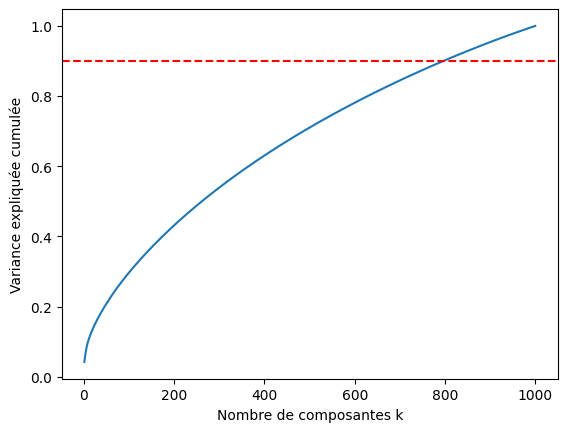

[INFO] Nombre de composantes retenues : 500 (variance cumulative ≥ 90%)


In [17]:
lsa.fit(cleaned_corpus)

In [6]:
vocab_size = len(set(word for doc in cleaned_corpus.values() for word in doc["text"].split()))
print("Taille du vocabulaire :", vocab_size)


Taille du vocabulaire : 98543


In [18]:
from beir.retrieval.evaluation import EvaluateRetrieval

def evaluate_model(model, queries, qrels, k_values=[10, 100]):
    results = {}
    max_k = max(k_values)

    for qid in qrels:
        if qid not in queries:
            continue
        query_text = queries[qid]["text"]
        scores = model.search(query_text, top_k=max_k)
        results[qid] = {doc_id: float(score) for doc_id, score in scores}

    ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, results, k_values=k_values)
    return (ndcg, _map, recall, precision)

print(evaluate_model(lsa, cleaned_queries, qrels))

({'NDCG@10': 0.08366, 'NDCG@100': 0.13421}, {'MAP@10': 0.05796, 'MAP@100': 0.06697}, {'Recall@10': 0.11018, 'Recall@100': 0.31225}, {'P@10': 0.02577, 'P@100': 0.00789})


In [9]:
import sys
import os

# Ajouter le dossier racine du projet
project_root = r'c:\Users\Axel\Desktop\lsa rocchio knn\BEIR_lsa_rocchio_knn'
sys.path.append(project_root)

# Maintenant tu peux importer
from src.models.bm25 import BM25Model
from src.models.lsa import LSAModel


In [11]:
from src.models.bm25 import BM25Model
from src.models.lsa import LSAModel

bm25 = BM25Model()
bm25.fit(cleaned_corpus)
print("bm25 chargé")

lsa = LSAModel()
lsa.fit(cleaned_corpus)
print("lsa chargé")

lsa_rocchio = LSAModel(rocchio_prf=True)
lsa_rocchio.fit(cleaned_corpus)
print("rocchio chargé")

lsa_knn = LSAModel(knn_search=True)
lsa_knn.fit(cleaned_corpus)
print("knn chargé")

bm25 chargé
[INFO] Composantes retenues : 700 (≥ 90% variance)
lsa chargé
[INFO] Composantes retenues : 700 (≥ 90% variance)
rocchio chargé
[INFO] Composantes retenues : 700 (≥ 90% variance)
knn chargé


In [12]:
models = [bm25, lsa, lsa_rocchio, lsa_knn]
for model in models:
    res = evaluate_model(model, cleaned_queries, qrels)
    print(f'{model}:\nNDGC@10: {res[0]["NDCG@10"]}, Recall@100: {res[2]["Recall@100"]}')

<src.models.bm25.BM25Model object at 0x000002975140BAA0>:
NDGC@10: 0.23106, Recall@100: 0.51356
<src.models.lsa.LSAModel object at 0x000002975E8BC6E0>:
NDGC@10: 0.0896, Recall@100: 0.33962
<src.models.lsa.LSAModel object at 0x0000029752CDBE60>:
NDGC@10: 0.0878, Recall@100: 0.33442
<src.models.lsa.LSAModel object at 0x00000297656EB380>:
NDGC@10: 0.0896, Recall@100: 0.33962
